# **MVP: Modelo de Machine Learning para Previsão de Recompra de Clientes**

MVP: Machine Learning & Analytics

Autor: Gabrielle Cristina Caldas Castro

Data: 01/06/2026

Matrícula:

Dataset: https://archive.ics.uci.edu/dataset/352/online+retail

# 1. Escopo, objetivo e definição do problema

## Contexto e objetivo

Lojas virtuais frequentemente buscam entender o comportamento de compra dos seus clientes para melhorar suas estratégias de retenção e aumentar as vendas.

Neste projeto, foi desenvolvido um modelo de Machine Learning a partir da base Online Retail, com o objetivo de prever se um cliente possui perfil de recompra, ou seja, se ele tende a voltar a comprar na loja com base no seu histórico de compras.

## Tipo de tarefa

Classificação binária. O modelo tem como objetivo prever:

1 = Cliente recorrente
0 = Cliente não recorrente

## Área de aplicação

E-commerce e análise de comportamento de clientes.

## Valor para o negócio

Com a identificação de clientes com maior probabilidade de recompra, a empresa pode direcionar campanhas de marketing, melhorar estratégias de retenção e otimizar ações de relacionamento com clientes.

## 2. Reprodutibilidade e ambiente

Foram utilizadas bibliotecas para manipulação de dados (Pandas e NumPy), visualização (Matplotlib e Seaborn) e Machine Learning (Scikit-learn).

Para garantir a reprodutibilidade dos resultados, foi definida uma seed fixa (42), utilizada nas etapas de divisão dos dados e treinamento dos modelos.

Além disso, foi utilizado pipeline para garantir consistência entre as etapas de pré-processamento e modelagem, evitando vazamento de dados.


In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [44]:
import sklearn
import matplotlib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Pandas: 2.2.2
NumPy: 2.0.2
Scikit-Learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2


#3. Dados: carga, entendimento e qualidade

# 3. Dados: carga, entendimento e qualidade

Para o desenvolvimento deste projeto foi utilizado o dataset Online Retail, disponível na UCI Machine Learning Repository. A base contém registros de uma loja de varejo online do Reino Unido entre dezembro de 2010 e dezembro de 2011.

A base foi escolhida por conter informações detalhadas sobre clientes, produtos e compras, permitindo a análise de padrões de consumo e comportamento de recompra. E por se tratar de uma base pública, não há informações que permitam a identificação dos clientes.

As principais variáveis incluem o identificador do cliente, produtos comprados, quantidade adquirida, data da compra, preço unitário e país de origem da transação.

Antes da etapa de modelagem, foram realizadas etapas de limpeza e preparação dos dados, incluindo remoção de valores ausentes em CustomerID, tratamento de inconsistências e criação de variáveis agregadas por cliente, como quantidade de pedidos, total de itens comprados, valor total gasto, ticket médio, média de itens por pedido, quantidade de produtos diferentes adquiridos e valor médio por item.

Como o objetivo do projeto é prever o comportamento de recompra dos clientes, os dados foram estruturados em nível de cliente, garantindo que cada observação representasse o histórico consolidado de compras de cada consumidor.

In [45]:
##carga de dados

url = "https://raw.githubusercontent.com/gabicaldascastro-lab/MVP_Recomendacao/main/Online%20Retail.xlsx"

df = pd.read_excel(url)

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [46]:
# verificacoes iniciais

display(df.sample(5))

print("\nFormato:", df.shape)

print("\nTipos das variáveis:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isna().sum())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom



Formato: (541909, 8)

Tipos das variáveis:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Valores ausentes por coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


#Principais observações

A análise inicial mostrou que a base possui mais de 540 mil registros e contém informações sobre produtos, clientes e transações.

Também foi identificado um número significativo de valores ausentes na variável CustomerID, que será utilizada para identificar os clientes e construir o modelo de classificação. Por esse motivo, esses registros serão tratados na etapa de preparação dos dados.

#3.1 Análise exploratória resumida (EDA)

In [47]:
### Top 10 de quantidade comprada

df['Quantity'].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


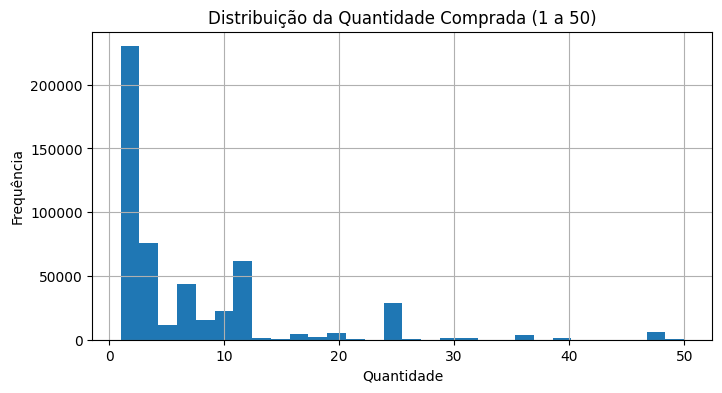

In [48]:
plt.figure(figsize=(8,4))

df[df['Quantity'].between(1,50)]['Quantity'].hist(bins=30)

plt.title('Distribuição da Quantidade Comprada (1 a 50)')
plt.xlabel('Quantidade')
plt.ylabel('Frequência')

plt.show()

A análise da variável Quantity mostrou valores altos positivos e negativos, com registros variando de -80.995 a 80.995 unidades. Como esses valores distorciam a visualização da distribuição principal dos dados, foi utilizada uma faixa entre 1 e 50 unidades para uma melhor análise exploratória.

Observa-se que a maior parte das compras é composta por pequenas quantidades de produtos, entre 1 e 10 unidades por transação. Esse comportamento sugere que a maioria dos clientes realiza compras de poucos itens por vez.


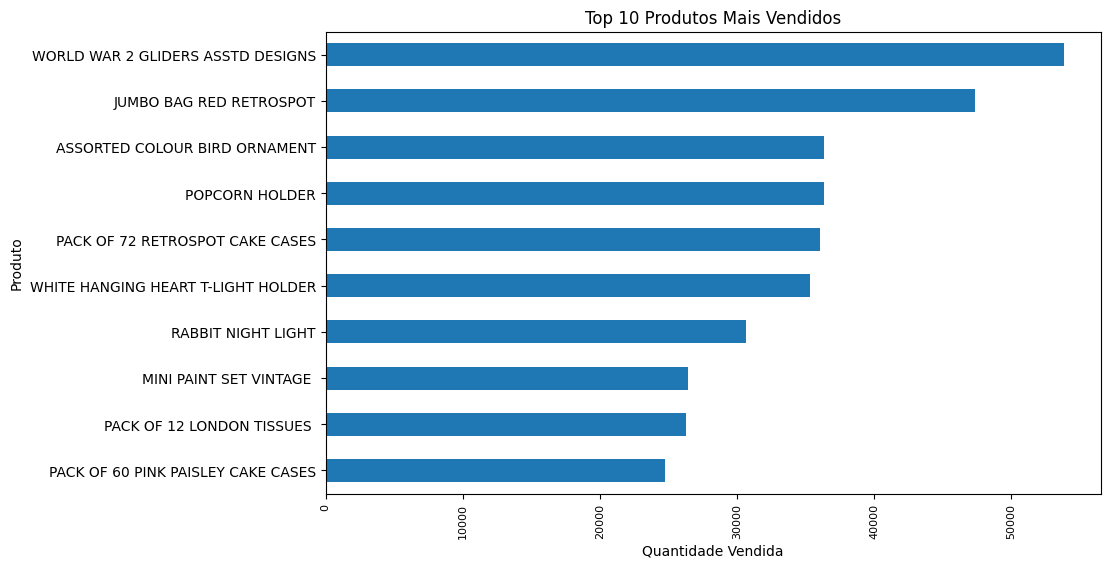

In [49]:
### Top 10 produtos mais vendidos

top_produtos = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_produtos.sort_values().plot(kind='barh')

plt.xticks(fontsize=8, rotation=90)

plt.title('Top 10 Produtos Mais Vendidos')
plt.xlabel('Quantidade Vendida')
plt.ylabel('Produto')

plt.show()

Ao analisar os produtos mais vendidos entre os destaques estão planadores temáticos, sacos organizadores, enfeites decorativos, suportes para velas e luminárias. Essa diversidade sugere que a loja atende diferentes necessidades dos consumidores, concentrando boa parte das vendas em produtos de baixo valor unitário e compra frequente.

A análise dos produtos mais vendidos contribui para uma melhor compreensão do comportamento de compra dos clientes e do contexto comercial da base utilizada neste projeto.

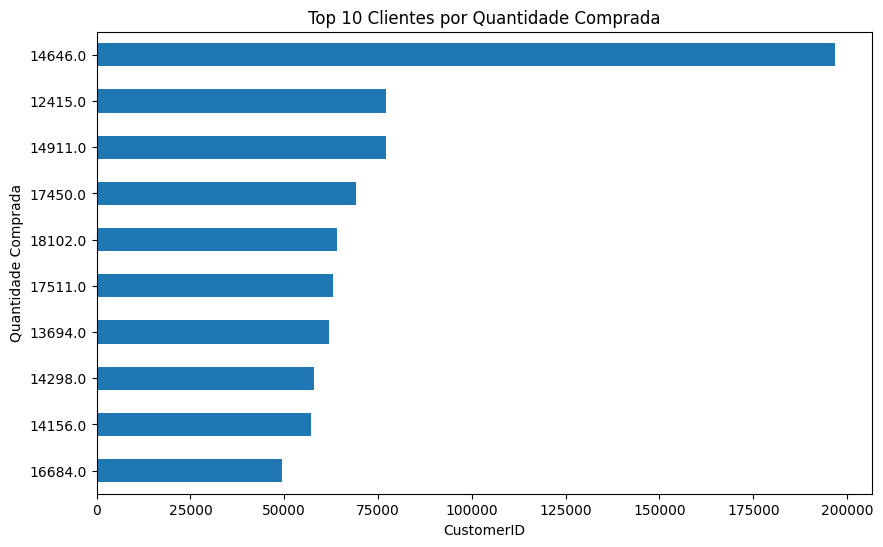

In [50]:
### Top 10 clientes com maior volume de compras

top_clientes = (
    df.groupby('CustomerID')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_clientes.sort_values().plot(kind='barh')

plt.title('Top 10 Clientes por Quantidade Comprada')
plt.xlabel('CustomerID')
plt.ylabel('Quantidade Comprada')

plt.show()

A análise dos clientes com maior volume de compras mostra que existe uma concentração de compras em um grupo pequeno de consumidores.

Esse comportamento é comum em ambientes de e-commerce, alguns clientes realizam compras com maior frequência ou em maior volume. A identificação dessas diferenças reforça a importância de analisar o histórico de compras individualmente para compreender o comportamento de recompra.

## 4. Definição do target, variáveis e divisão dos dados

Nesta etapa foi realizada a preparação dos dados para a modelagem. Foram removidos os registros sem identificação de cliente (CustomerID), uma vez que o objetivo do projeto é analisar o comportamento de recompra dos consumidores.

Em seguida, foram eliminadas transações com quantidades negativas, que representam devoluções e poderiam distorcer a análise do comportamento de compra.

Após a limpeza dos dados, foram criadas variáveis agregadas por cliente, permitindo representar o histórico de compras de cada consumidor por meio de indicadores como valor gasto, quantidade de itens adquiridos e diversidade de produtos comprados.

Por fim, foi definida a variável alvo (Cliente_Recorrente), indicando se o cliente realizou mais de um pedido durante o período analisado.

In [51]:
print("Clientes únicos:", df['CustomerID'].nunique())
print("Registros sem CustomerID:", df['CustomerID'].isna().sum())

# Removendo registros sem cliente identificado
df_clientes = df.dropna(subset=['CustomerID']).copy()

print("\nFormato após remoção:")
print(df_clientes.shape)

Clientes únicos: 4372
Registros sem CustomerID: 135080

Formato após remoção:
(406829, 8)


In [52]:
# Valor total de cada item vendido

df_clientes['ValorCompra'] = (df_clientes['Quantity'] * df_clientes['UnitPrice'])
print(df_clientes['ValorCompra'].describe())

# Mantendo apenas compras válidas
df_clientes = df_clientes[df_clientes['Quantity'] > 0].copy()

print("\nFormato após limpeza:")
print(df_clientes.shape)

count    406829.000000
mean         20.401854
std         427.591718
min     -168469.600000
25%           4.200000
50%          11.100000
75%          19.500000
max      168469.600000
Name: ValorCompra, dtype: float64

Formato após limpeza:
(397924, 9)


In [53]:
clientes_ml = df_clientes.groupby('CustomerID').agg(Total_Pedidos=('InvoiceNo', 'nunique'),Total_Itens=('Quantity', 'sum'),Valor_Total=('ValorCompra', 'sum')).reset_index()
clientes_ml.head()

,CustomerID,Total_Pedidos,Total_Itens,Valor_Total
0,12346.0,1,74215,77183.60
1,12347.0,7,2458,4310.00
2,12348.0,4,2341,1797.24
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40


In [54]:
# Ticket médio

clientes_ml['Ticket_Medio'] = (clientes_ml['Valor_Total'] / clientes_ml['Total_Pedidos'])

# Média de itens por pedido

clientes_ml['Media_Itens_Por_Pedido'] = (clientes_ml['Total_Itens'] / clientes_ml['Total_Pedidos'])

# Quantidade de produtos diferentes comprados

produtos_diferentes = (df_clientes.groupby('CustomerID')['StockCode']
    .nunique()
    .reset_index()
    .rename(columns={'StockCode':'Produtos_Diferentes'}))

clientes_ml = clientes_ml.merge(produtos_diferentes, on='CustomerID', how='left')

# Valor médio por item

clientes_ml['Valor_Medio_Item'] = (clientes_ml['Valor_Total'] / clientes_ml['Total_Itens'])

clientes_ml.head()

,CustomerID,Total_Pedidos,Total_Itens,Valor_Total,Ticket_Medio,Media_Itens_Por_Pedido,Produtos_Diferentes,Valor_Medio_Item
0,12346.0,1,74215,77183.60,77183.600000,74215.000000,1,1.040000
1,12347.0,7,2458,4310.00,615.714286,351.142857,103,1.753458
2,12348.0,4,2341,1797.24,449.310000,585.250000,22,0.767723
3,12349.0,1,631,1757.55,1757.550000,631.000000,73,2.785341
4,12350.0,1,197,334.40,334.400000,197.000000,17,1.697462


In [55]:
clientes_ml['Cliente_Recorrente'] = (clientes_ml['Total_Pedidos'] > 1).astype(int)

print(clientes_ml['Cliente_Recorrente'].value_counts())

clientes_ml.head()

Cliente_Recorrente
1    2845
0    1494
Name: count, dtype: int64


,CustomerID,Total_Pedidos,Total_Itens,Valor_Total,Ticket_Medio,Media_Itens_Por_Pedido,Produtos_Diferentes,Valor_Medio_Item,Cliente_Recorrente
0,12346.0,1,74215,77183.60,77183.600000,74215.000000,1,1.040000,0
1,12347.0,7,2458,4310.00,615.714286,351.142857,103,1.753458,1
2,12348.0,4,2341,1797.24,449.310000,585.250000,22,0.767723,1
3,12349.0,1,631,1757.55,1757.550000,631.000000,73,2.785341,0
4,12350.0,1,197,334.40,334.400000,197.000000,17,1.697462,0


### Definição das variáveis

Foram selecionadas variáveis relacionadas ao volume de compras, valor gasto e diversidade de produtos adquiridos.

A variável Total_Pedidos foi utilizada apenas para construir a variável alvo e não foi incluída como feature do modelo, evitando vazamento de informação (data leakage).

In [56]:
features = ['Total_Itens','Valor_Total','Ticket_Medio','Media_Itens_Por_Pedido','Produtos_Diferentes','Valor_Medio_Item']

target = 'Cliente_Recorrente'

X = clientes_ml[features]
y = clientes_ml[target]

print("Número de features:", len(features))
print("Target:", target)

Número de features: 6
Target: Cliente_Recorrente


In [57]:
from sklearn.model_selection import train_test_split

SEED = 42

# 70% treino e 30% temporário

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Divide os 30% em 15% validação e 15% teste

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (3037, 6)
Validação: (651, 6)
Teste: (651, 6)


## 5. Tratamento de dados e Pipeline de pré-processamento

Nesta etapa foi criado um pipeline de pré-processamento para organizar as etapas de preparação dos dados antes do treinamento dos modelos.

Também foi revisada a divisão dos dados. Durante o desenvolvimento deste trabalho, optei por separar os dados em treino, validação e teste, para reduzir a sorte estatística nos resultados. Assim, os modelos podem ser comparados na base de validação antes da avaliação final na base de teste, tornando a escolha do melhor modelo mais confiável.


In [58]:
# Identificando colunas numéricas e categóricas

num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("int", "float"))]
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['Total_Itens', 'Valor_Total', 'Ticket_Medio', 'Media_Itens_Por_Pedido', 'Produtos_Diferentes', 'Valor_Medio_Item']
Colunas categóricas: []


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Pipeline para variáveis numéricas

numeric_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler",StandardScaler())])

# Pipeline de pré-processamento

preprocess = ColumnTransformer(transformers=[("num", numeric_pipe,num_cols)])

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Total_Itens', 'Valor_Total', 'Ticket_Medio',
                                  'Media_Itens_Por_Pedido',
                                  'Produtos_Diferentes', 'Valor_Medio_Item'])])

### 6. Baseline e modelos candidatos

Nesta etapa foram treinados diferentes modelos de classificação com o objetivo de prever o comportamento de recompra dos clientes.

Inicialmente foi utilizado um modelo baseline simples. Em seguida, foram treinados os modelos de Regressão Logística e Random Forest.

O objetivo desta etapa é realizar uma comparação entre os modelos e os dois que apresentarem um melhor desempenho será aplicada a etapa de validação.

In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

modelos = {
    "Baseline": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED)
}

resultados = []

for nome, modelo in modelos.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", modelo)])
    pipe.fit(X_train, y_train)
    resultados.append([nome, accuracy_score(y_train, pipe.predict(X_train))])

pd.DataFrame(resultados, columns=["Modelo", "Acuracia"]).sort_values(by="Acuracia", ascending=False)

,Modelo,Acuracia
2,Random Forest,1.000000
1,Logistic Regression,0.906487
0,Baseline,0.655581


###Considerações:
Os resultados iniciais mostraram que os modelos de Machine Learning apresentaram desempenho superior ao da baseline.

O modelo Random Forest teve acurácia de 100% no treinamento, a Regressão Logística alcançou aproximadamente 90,6%. Apesar do desempenho superior do Random Forest nesta etapa, resultados muito elevados no treino podem indicar que o modelo pode ter decorado os dados (overfitting).

Os modelos Random Forest e Regressão Logística irão para a etapa de validação, na qual serão avaliados em dados que não participaram do treinamento. Essa será a prova de fogo que permitirá uma comparação mais confiável antes da escolha do modelo final.

### 7. Validação dos modelos candidatos
Após o treinamento inicial, os modelos Regressão Logística e Random Forest foram avaliados utilizando o conjunto de validação.

Essa etapa tem como objetivo verificar qual modelo apresenta melhor capacidade de generalização em dados que não participaram do treinamento. Dessa forma, a escolha do modelo final torna-se mais confiável e menos dependente da sorte estatística.

In [61]:
from sklearn.metrics import accuracy_score

resultados_val = pd.DataFrame({"Modelo": ["Logistic Regression", "Random Forest"],"Acuracia_Validacao": [accuracy_score(y_val, lr_model.predict(X_val)),accuracy_score(y_val, rf_model.predict(X_val))]
}).sort_values(by="Acuracia_Validacao",ascending=False)

resultados_val

,Modelo,Acuracia_Validacao
1,Random Forest,0.987711
0,Logistic Regression,0.895545


Após a avaliação dos modelos no conjunto de validação, o modelo Random Forest teve um desempenho superior ao da Regressão Logística, demostrando melhor capacidade de generalização para dados não utilizados durante o treinamento.

Dessa forma, o modelo Random Forest foi selecionado para a etapa final de avaliação no conjunto de teste.

###8. Avaliação final, análise de erros e limitações

Nesta etapa foi realizada a avaliação final do modelo selecionado utilizando o conjunto de teste, que permaneceu isolado durante todo o desenvolvimento do projeto.

Além da análise do desempenho geral, foi utilizada a matriz de confusão para identificar possíveis erros de classificação e compreender melhor o comportamento do modelo.

In [62]:
from sklearn.metrics import accuracy_score

y_pred_test = rf_model.predict(X_test)

print("Acurácia no conjunto de teste:", accuracy_score(y_test, y_pred_test))

Acurácia no conjunto de teste: 0.9953917050691244


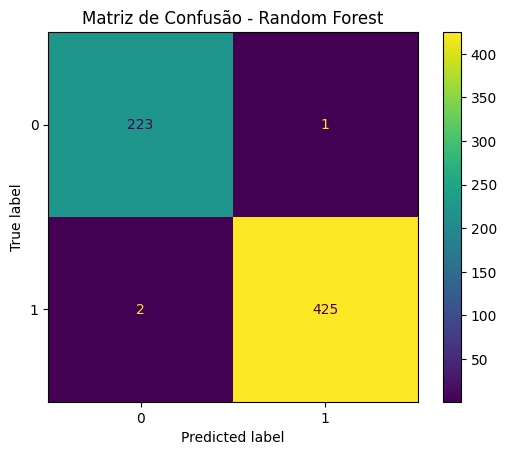

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

plt.title("Matriz de Confusão - Random Forest")
plt.show()

A avaliação final mostrou que o modelo Random Forest apresentou excelente desempenho no conjunto de teste, alcançando aproximadamente 99,5% de acurácia.

A matriz de confusão demonstra que a maior parte dos clientes foi classificada corretamente. Foram observados apenas três erros de classificação em todo o conjunto de teste, sendo um cliente não recorrente classificado como recorrente e dois clientes recorrentes classificados como não recorrentes.

Esses resultados indicam que as variáveis criadas a partir do histórico de compras conseguiram capturar padrões relevantes relacionados ao comportamento de recompra dos clientes.


De forma geral, os resultados demonstram que o modelo foi capaz de identificar com alta precisão clientes com perfil de recompra, atendendo ao objetivo proposto para este projeto. Mas, algumas limitações devem ser consideradas. A definição de cliente recorrente foi baseada na quantidade de pedidos realizados, não levando em conta fatores externos que também podem influenciar futuras compras.

###9. Engenharia de atributos (detalhe)

Com o objetivo de representar melhor o comportamento de compra dos clientes, foram criadas novas variáveis a partir dos dados transacionais originais.
As variáveis desenvolvidas foram:

* **Total_Pedidos:** quantidade de pedidos realizados pelo cliente.
* **Total_Itens:** quantidade total de itens comprados.
* **Valor_Total:** valor total gasto pelo cliente.
* **Ticket_Medio:** valor médio gasto por pedido.
* **Media_Itens_Por_Pedido:** quantidade média de itens adquiridos em cada pedido.
* **Produtos_Diferentes:** quantidade de produtos distintos comprados.
* **Valor_Medio_Item:** valor médio gasto por item.

A análise das importâncias mostra quais características tiveram maior influência na previsão da recompra dos clientes. A criação dessas variáveis permitiu transformar os registros individuais de compra em indicadores mais representativos do perfil de consumo de cada cliente, contribuindo para o treinamento e desempenho dos modelos de classificação.


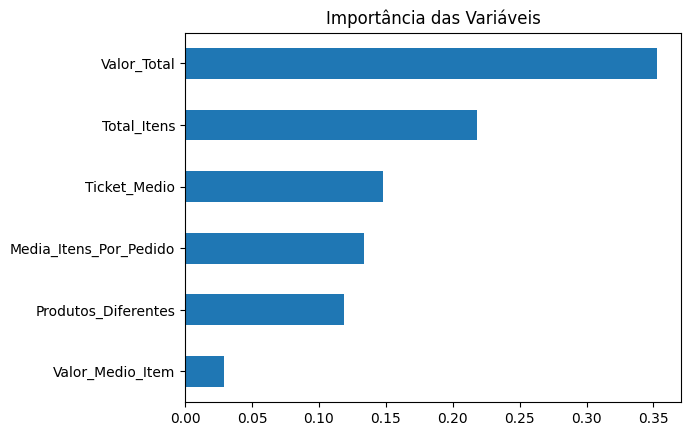

In [64]:
import pandas as pd

importancias = pd.Series(rf_model.named_steps["model"].feature_importances_,index=features).sort_values()
importancias.plot(kind="barh")

plt.title("Importância das Variáveis")
plt.show()

###10. Boas práticas e rastreabilidade

O projeto seguiu boas práticas de Machine Learning durante todas as etapas de desenvolvimento.

Foi utilizada uma seed fixa para garantir a reprodutibilidade dos resultados, além da divisão dos dados em conjuntos de treino, validação e teste. Essa estratégia permitiu selecionar o melhor modelo de forma mais confiável e reduzir a influência da sorte estatística nos resultados.

Também foi utilizado um pipeline de pré-processamento para garantir consistência nas etapas de treinamento e avaliação dos modelos, evitando vazamento de dados.

Por fim, foi definida uma baseline simples para comparação e foram avaliados diferentes algoritmos de classificação antes da escolha do modelo final.

### 11. Conclusão e próximos passos

Neste projeto foi desenvolvido um modelo de Machine Learning com o objetivo de identificar clientes com maior probabilidade de recompra a partir do histórico de compras.

Ao longo do desenvolvimento foram realizadas etapas de análise exploratória, tratamento dos dados, criação de variáveis, construção de pipelines e comparação entre diferentes modelos de classificação.

Inicialmente foi utilizada uma baseline simples como referência de desempenho. Em seguida, foram avaliados os modelos Regressão Logística e Random Forest. Após a etapa de validação, o Random Forest apresentou o melhor desempenho e foi selecionado para a avaliação final.

No conjunto de teste, o modelo alcançou aproximadamente 99,5% de acurácia, demonstrando alta capacidade de identificar corretamente clientes recorrentes e não recorrentes.

De forma geral, os resultados mostram que o comportamento de recompra pode ser previsto com boa precisão a partir do histórico de compras dos clientes.

Como trabalhos futuros, seria interessante explorar novas variáveis relacionadas ao comportamento de consumo, testar outros algoritmos de Machine Learning e avaliar o desempenho do modelo em bases de dados de diferentes períodos.


###12. Salvando artefatos (modelos e pipeline)

Após a seleção do melhor modelo, foi realizado o salvamento do Random Forest utilizando a biblioteca Joblib. Essa etapa permite reutilizar o modelo futuramente sem a necessidade de realizar um novo treinamento.

In [65]:
import joblib

joblib.dump(rf_model, "modelo_random_forest.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
